## Cloning Quasars
Download the SDSS quasar data.
- Upsample this distribution in two ways, using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)

(Hint: `scipy.stats` is your best friend)

- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data 

(Hint: `astropy.cosmology` is another close friend).

### Importing the data and plotting it in a histogram

In [7]:
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']

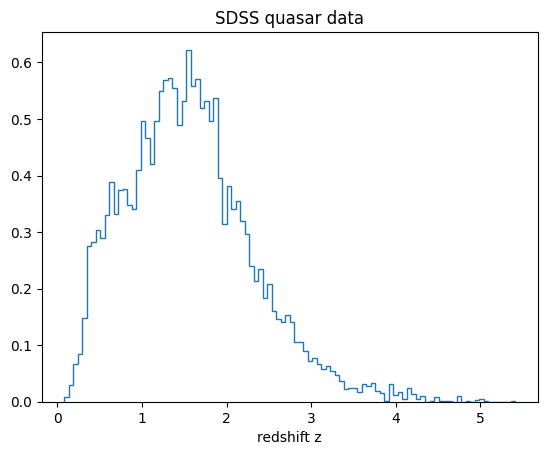

In [8]:
import numpy as np
import random as r
import matplotlib.pyplot as plt
from scipy import stats, interpolate
from scipy.optimize import curve_fit
from scipy.special import factorial
from scipy.stats import poisson

Ndata = 10000

z.sort()

n, bins, patches = plt.hist(z, int(np.sqrt(Ndata)), histtype = 'step', density = True)
plt.title('SDSS quasar data')
plt.xlabel('redshift z')
#each bin value is one edge:
#bins[0] is the left edge of the first bin, bins[1] is the right one. 
#Finally bins[sqrt(Ndata) + 1] is the right edge of the last bin.
plt.show()

### Rejection sampling

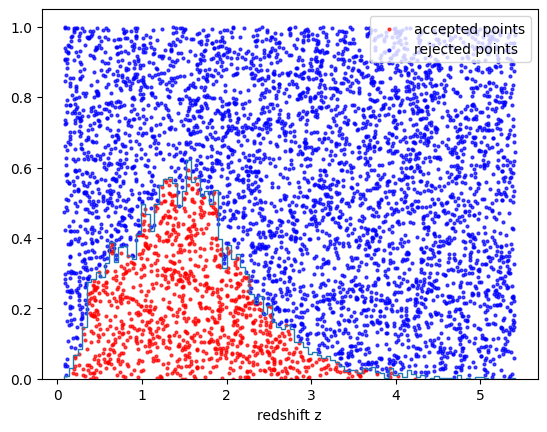

In [9]:
Nsamples = 1000

r_samples = np.empty([2, Nsamples])

#finding in which bin we are
def find_bin(x, bins):
    for i in range(len(bins)):
            if (x >= bins[i] and x < bins[i + 1]):  return i

#generating numbers with a uniform distribution and rejecting all values over the data histogram
i = 0
while(i < Nsamples):
    x = r.uniform(bins[0], bins[len(bins) - 1]) #x in the total bins range
    y = r.uniform(0.0, 1.0) #y between 0 and 1
    in_bin = find_bin (x, bins) #finding the bin which corresponds to the random x value
    if (y < n[in_bin]): #if y under the n of data in the bin -> we save the value
        #print('x in range:', bins[in_bin], '-', bins[in_bin + 1], 'x:', x)
        #print('y must be under:', n[in_bin], 'y:', y, '\n')
        r_samples[0][i] = x
        r_samples[1][i] = y
        i+=1
        acc = plt.scatter(x, y, c = 'red', s=4, alpha = 0.7)
    else: rej = plt.scatter(x, y, c = 'blue', s= 4, alpha = 0.7)

plt.hist(z, int(np.sqrt(Ndata)), histtype= 'step', density = True, label='SDSS data')
plt.legend((acc, rej), ('accepted points', 'rejected points'), scatterpoints=1, loc = 'upper right')
plt.xlabel('redshift z')
plt.show()

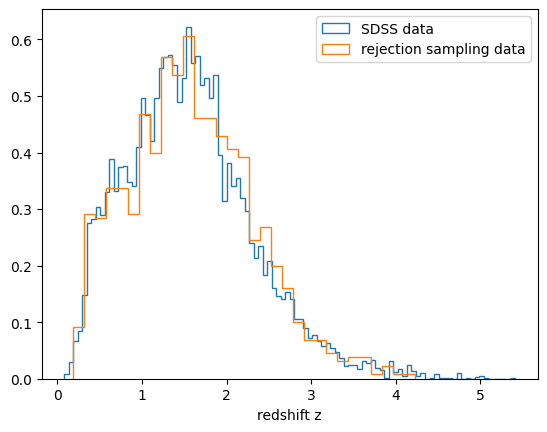

In [10]:
plt.hist(z, int(np.sqrt(Ndata)), histtype= 'step', density = True, label='SDSS data')
plt.hist(r_samples[0], int(np.sqrt(Nsamples)), histtype= 'step', density = True, label='rejection sampling data')
plt.legend()
plt.xlabel('redshift z')
plt.show()

### Inverse transform sampling

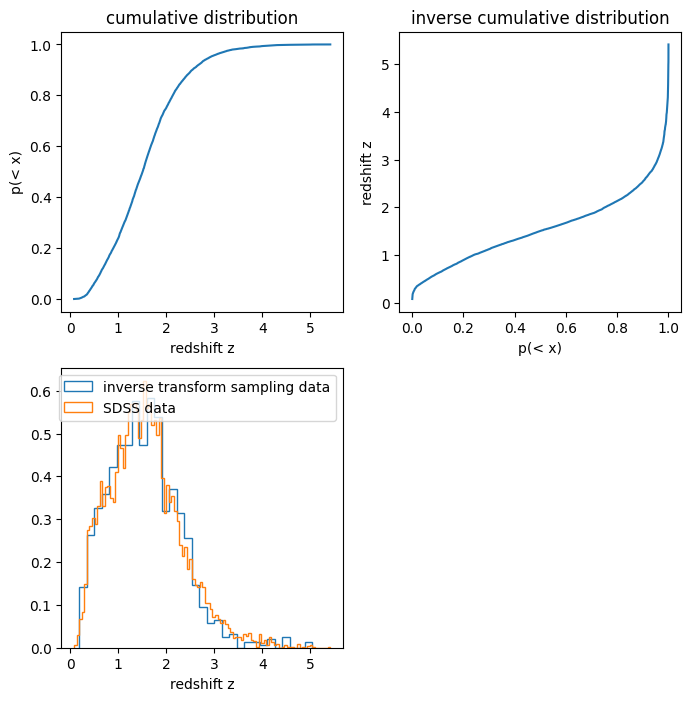

In [11]:
Nsamples = 1000
cdf = np.arange(1, len(z) + 1) / len(z)

fig = plt.figure(figsize=(8, 8))

#cumulative distribution plot
ax = fig.add_subplot(221)
ax.plot(z, cdf)
ax.set_title('cumulative distribution')
ax.set_xlabel('redshift z')
ax.set_ylabel('p(< x)')

#inverse cumulative distribution plot
ax = fig.add_subplot(222)
ax.plot(cdf, z)
ax.set_title('inverse cumulative distribution')
ax.set_ylabel('redshift z')
ax.set_xlabel('p(< x)')

tck = interpolate.splrep(cdf, z)
u = np.random.uniform(size=Nsamples)
it_samples = interpolate.splev(u, tck)
ax = fig.add_subplot(223)
ax.hist(it_samples, int(np.sqrt(Nsamples)), histtype= 'step', density = True, label='inverse transform sampling data')
ax.hist(z, int(np.sqrt(Ndata)), histtype= 'step', density = True, label='SDSS data')
ax.legend()
ax.set_xlabel('redshift z')
plt.show()

### Cloning with EmpiricalDistribution

Text(0, 0.5, 'N(x)')

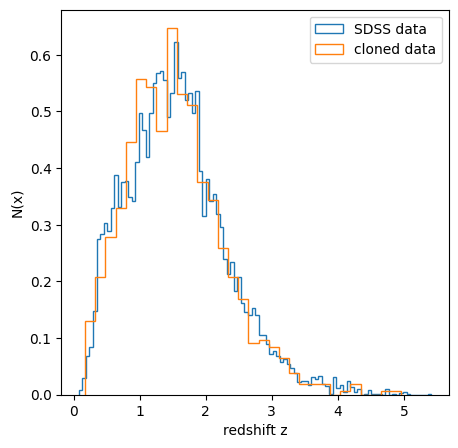

In [12]:
from astroML.density_estimation import EmpiricalDistribution

Nclone = 1000
fig = plt.figure(figsize=(5, 5))

z_cloned = EmpiricalDistribution(z).rvs(Nclone)

ax = fig.add_subplot()
n, bins, patches = ax.hist(z, int(np.sqrt(Ndata)), histtype= 'step', density = True, label='SDSS data')
n, bins, patches = ax.hist(z_cloned, int(np.sqrt(Nclone)), histtype= 'step', density = True, label='cloned data')
ax.legend()
ax.set_xlabel('redshift z')
ax.set_ylabel('N(x)')

In [40]:
from astropy.cosmology import Planck15
V = []
z_new= np.linspace(0, 7, 100)
for zi in z_new:
    V.append( Planck15.differential_comoving_volume(zi).value )

V = np.array(V)

#differential volume for a given redshift
n_theory = V
#normalized on our histogram
n_theory = n_theory/max(n_theory) * max(n)

In [41]:
max(n_theory)

np.float64(0.647124157766384)

Text(0, 0.5, 'N(x)')

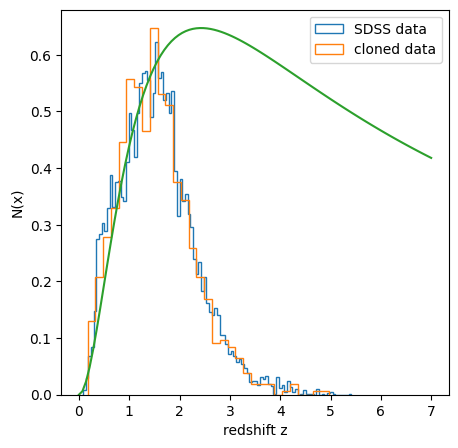

In [42]:
fig = plt.figure(figsize=(5, 5))

ax = fig.add_subplot()
n, bins, patches = ax.hist(z, int(np.sqrt(Ndata)), histtype= 'step', density = True, label='SDSS data')
n, bins, patches = ax.hist(z_cloned, int(np.sqrt(Nclone)), histtype= 'step', density = True, label='cloned data')
ax.plot(z_new, n_theory)
ax.legend()
ax.set_xlabel('redshift z')
ax.set_ylabel('N(x)')

we don't see quasars at z around 4, some effects to take into account are: selection bias (harder and harder to observe at higher z) and the number density of quasars is not actually constant with redshift as we have assumed.

### Are our new samples consistent with our original distribution?

In [7]:
from scipy.stats import ks_2samp

In [8]:
print('Rejection sampling:', ks_2samp(r_samples[0], z))
print('\nInverse transform sampling:', ks_2samp(it_samples, z))

Rejection sampling: KstestResult(statistic=np.float64(0.033), pvalue=np.float64(0.2705559946279908), statistic_location=np.float64(0.871509955793626), statistic_sign=np.int8(1))

Inverse transform sampling: KstestResult(statistic=np.float64(0.0247), pvalue=np.float64(0.628556489933488), statistic_location=np.float64(1.9032054293067742), statistic_sign=np.int8(1))


Taking a significance of $\alpha$ = 0.05, both sampling methods pass the test: our new samples are consistent with the original distribution.